# Assignment: Xarray Fundamentals with Atmospheric Radiation Data

In [5]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

In [6]:
import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None,  downloader=pooch.HTTPDownloader(verify=False)
)
print(fname)

/home/yk3149/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


## 1) Opening data and examining metadata

### 1.1) Open the dataset and display its contents

In [7]:
ds = xr.open_dataset(fname)
ds

<xarray.Dataset> Size: 737MB
Dimensions:                      (time: 203, lat: 180, lon: 360)
Coordinates:
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB ...
    cldtemp_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldtau_total_day_mon         (time, lat, lon) float32 53MB ...
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

### 1.2) Print out the long_name attribute of each variable

In [8]:
maxlen = max(len(v) for v in ds.data_vars)

for v in ds.data_vars:
    long_name = ds[v].attrs.get("long_name", "NO long_name attribute")
    print(f"{v:<{maxlen}} : {long_name}")

toa_sw_all_mon              : Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon              : Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon             : Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon              : Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon              : Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon             : Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon              : Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon              : Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon             : Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
solar_mon                   : Incoming Solar Flux, Monthly Means
cldarea_total_daynig

In [9]:
def find_var(dataset, include_all=None, exclude_all=None):
    include_all = include_all or []
    exclude_all = exclude_all or []

    for v in dataset.data_vars:
        text = " ".join([
            v.lower(),
            dataset[v].attrs.get("long_name", "").lower(),
            dataset[v].attrs.get("standard_name", "").lower()
        ])
        if all(s.lower() in text for s in include_all) and not any(s.lower() in text for s in exclude_all):
            return v

    raise ValueError(f"Could not find variable with include={include_all}, exclude={exclude_all}")

## 2) Basic reductions, arithmetic, and plotting

### 2.1) Calculate the time-mean of the entire dataset

In [10]:
ds_mean = ds.mean(dim="time")
ds_mean

<xarray.Dataset> Size: 4MB
Dimensions:                      (lat: 180, lon: 360)
Coordinates:
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 51.52 51.52 ... 78.93
    cldpress_total_daynight_mon  (lat, lon) float32 259kB 486.5 486.5 ... 766.9
    cldtemp_total_daynight_mon   (lat, lon) float32 259kB 225.2 225.2 ... 247.9
    cldtau_total_day_mon         (lat, lon) float32 259kB 4.158 4.158 ... 4.821
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

In [11]:
# Incoming solar
solar_var = find_var(ds, include_all=["solar"], exclude_all=["clear"])

# Outgoing longwave all-sky
lw_var = find_var(ds, include_all=["longwave", "all"], exclude_all=["clear"])

# Outgoing shortwave all-sky
sw_var = find_var(ds, include_all=["shortwave", "all"], exclude_all=["clear", "solar"])

# Net TOA flux all-sky
net_var = find_var(ds, include_all=["net"], exclude_all=["clear"])

print("solar_var =", solar_var)
print("lw_var    =", lw_var)
print("sw_var    =", sw_var)
print("net_var   =", net_var)

solar_var = solar_mon
lw_var    = toa_lw_all_mon
sw_var    = toa_sw_all_mon
net_var   = toa_net_all_mon


### 2.2) From this, make a 2D plot of the the time-mean Top of Atmosphere (TOA) Longwave, Shortwave, and Incoming Solar Radiation

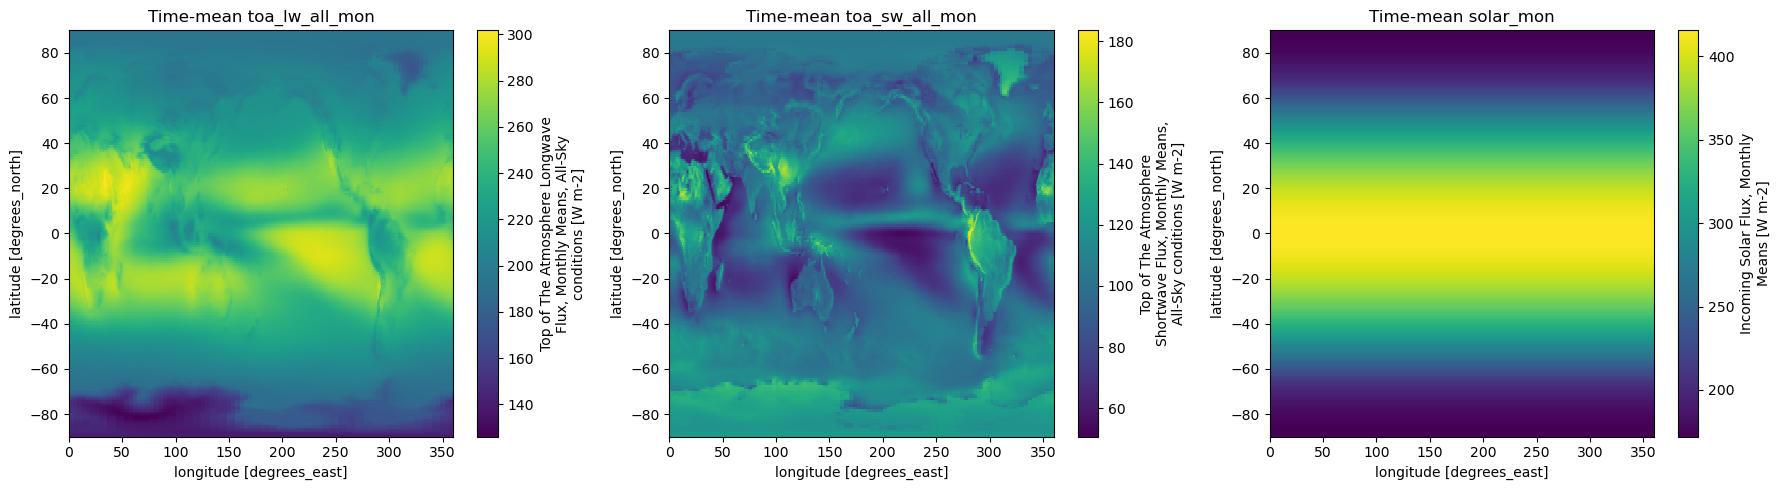

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ds_mean[lw_var].plot(ax=axes[0])
axes[0].set_title(f"Time-mean {lw_var}")

ds_mean[sw_var].plot(ax=axes[1])
axes[1].set_title(f"Time-mean {sw_var}")

ds_mean[solar_var].plot(ax=axes[2])
axes[2].set_title(f"Time-mean {solar_var}")

plt.tight_layout()
plt.show()

### 2.3) Add up the three variables above and verify (visually) that they are equivalent to the TOA net flux

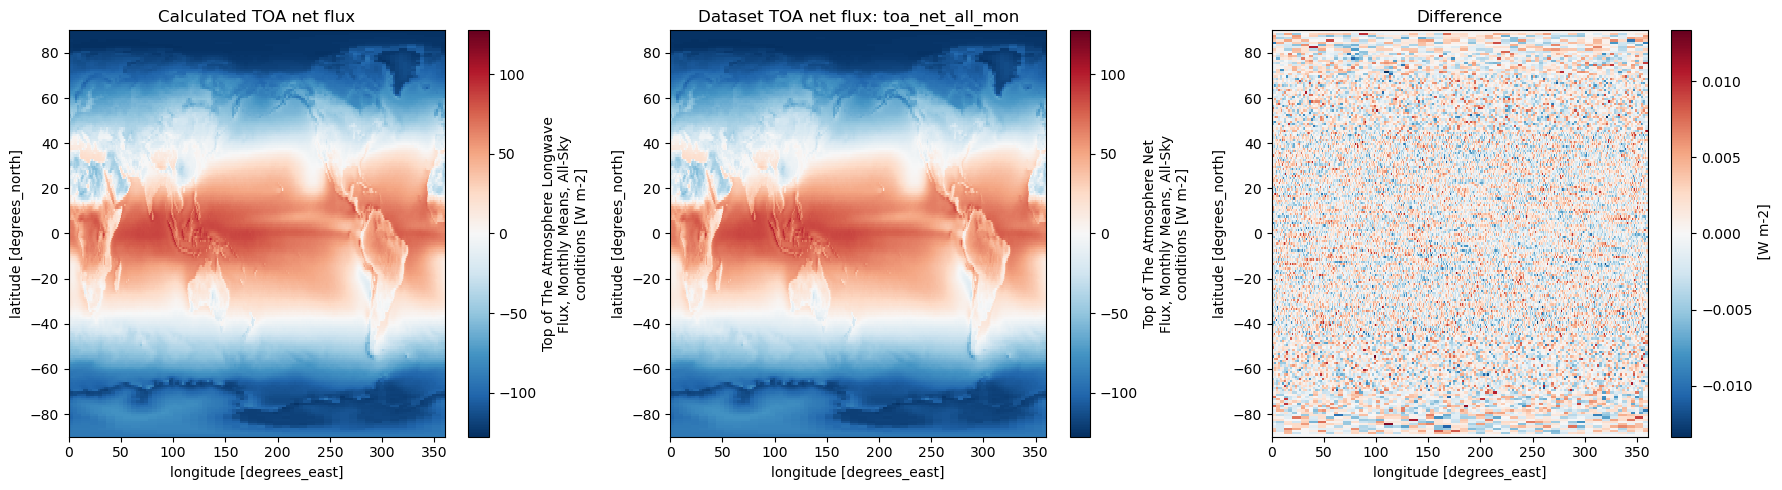

In [13]:
net_calc = ds_mean[solar_var] - ds_mean[sw_var] - ds_mean[lw_var]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

net_calc.plot(ax=axes[0])
axes[0].set_title("Calculated TOA net flux")

ds_mean[net_var].plot(ax=axes[1])
axes[1].set_title(f"Dataset TOA net flux: {net_var}")

(net_calc - ds_mean[net_var]).plot(ax=axes[2])
axes[2].set_title("Difference")

plt.tight_layout()
plt.show()

Incoming solar should be positive downward.
Outgoing SW and LW should be treated as losses from the planet, so the net absorbed flux is typically:
    net_calc = incoming_solar - outgoing_sw - outgoing_lw

## 3) Mean and weighted mean

### 3.1) Calculate the global (unweighted) mean of TOA net radiation

In [14]:
unweighted_mean = ds_mean[net_var].mean(dim=("lat", "lon"))
print("Unweighted global mean TOA net radiation:", float(unweighted_mean.values), ds_mean[net_var].attrs.get("units", ""))

Unweighted global mean TOA net radiation: -28.7290096282959 W m-2


### 3.2) Create a weight array proportional to cos(lambda)

In [15]:
weights = xr.DataArray(
    np.cos(np.deg2rad(ds["lat"])),
    coords={"lat": ds["lat"]},
    dims=("lat",),
    name="weights"
)

weights

<xarray.DataArray 'weights' (lat: 180)> Size: 720B
array([0.00872656, 0.02617699, 0.04361945, 0.06104851, 0.07845908,
       0.09584576, 0.11320324, 0.13052624, 0.14780948, 0.16504757,
       0.18223551, 0.19936794, 0.21643965, 0.23344542, 0.25037998,
       0.26723838, 0.28401536, 0.30070582, 0.3173047 , 0.33380693,
       0.35020736, 0.3665012 , 0.38268346, 0.3987491 , 0.4146933 ,
       0.43051115, 0.44619778, 0.4617486 , 0.47715878, 0.49242356,
       0.5075384 , 0.5224986 , 0.5372996 , 0.551937  , 0.56640625,
       0.58070296, 0.59482276, 0.6087614 , 0.62251467, 0.6360782 ,
       0.64944804, 0.66262007, 0.67559016, 0.68835455, 0.70090926,
       0.71325046, 0.72537434, 0.7372773 , 0.7489557 , 0.76040596,
       0.77162457, 0.78260815, 0.7933533 , 0.8038569 , 0.8141155 ,
       0.8241262 , 0.83388585, 0.8433914 , 0.85264015, 0.8616291 ,
       0.87035567, 0.87881714, 0.8870108 , 0.89493436, 0.90258527,
       0.9099613 , 0.9170601 , 0.9238795 , 0.9304176 , 0.9366722 ,
       0.9426415 , 0.94832367, 0.95371693, 0.95881975, 0.96363044,
       0.96814764, 0.9723699 , 0.976296  , 0.9799247 , 0.9832549 ,
       0.9862856 , 0.9890159 , 0.9914449 , 0.9935719 , 0.9953962 ,
       0.9969173 , 0.9981348 , 0.99904823, 0.99965733, 0.9999619 ,
       0.9999619 , 0.99965733, 0.99904823, 0.9981348 , 0.9969173 ,
       0.9953962 , 0.9935719 , 0.9914449 , 0.9890159 , 0.9862856 ,
       0.9832549 , 0.9799247 , 0.976296  , 0.9723699 , 0.96814764,
       0.96363044, 0.95881975, 0.95371693, 0.94832367, 0.9426415 ,
       0.9366722 , 0.9304176 , 0.9238795 , 0.9170601 , 0.9099613 ,
       0.90258527, 0.89493436, 0.8870108 , 0.87881714, 0.87035567,
       0.8616291 , 0.85264015, 0.8433914 , 0.83388585, 0.8241262 ,
       0.8141155 , 0.8038569 , 0.7933533 , 0.78260815, 0.77162457,
       0.76040596, 0.7489557 , 0.7372773 , 0.72537434, 0.71325046,
       0.70090926, 0.68835455, 0.67559016, 0.66262007, 0.64944804,
       0.6360782 , 0.62251467, 0.6087614 , 0.59482276, 0.58070296,
       0.56640625, 0.551937  , 0.5372996 , 0.5224986 , 0.5075384 ,
       0.49242356, 0.47715878, 0.4617486 , 0.44619778, 0.43051115,
       0.4146933 , 0.3987491 , 0.38268346, 0.3665012 , 0.35020736,
       0.33380693, 0.3173047 , 0.30070582, 0.28401536, 0.26723838,
       0.25037998, 0.23344542, 0.21643965, 0.19936794, 0.18223551,
       0.16504757, 0.14780948, 0.13052624, 0.11320324, 0.09584576,
       0.07845908, 0.06104851, 0.04361945, 0.02617699, 0.00872656],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Attributes:
    long_name:      latitude
    standard_name:  latitude
    units:          degrees_north
    valid_range:    [-90.  90.]

### 3.3) Redo your global mean TOA net radiation calculation with this weight factor

In [16]:
weighted_mean = ds_mean[net_var].weighted(weights).mean(dim=("lat", "lon"))
print("Weighted global mean TOA net radiation:", float(weighted_mean.values), ds_mean[net_var].attrs.get("units", ""))

Weighted global mean TOA net radiation: 0.8780902624130249 W m-2


### 3.4) Now that you have a weight factor, verify that the TOA incoming solar, outgoing longwave, and outgoing shortwave approximately match up with infographic shown in the first cell of this assignment

In [17]:
solar_global = ds_mean[solar_var].weighted(weights).mean(dim=("lat", "lon"))
lw_global = ds_mean[lw_var].weighted(weights).mean(dim=("lat", "lon"))
sw_global = ds_mean[sw_var].weighted(weights).mean(dim=("lat", "lon"))

print("Weighted global incoming solar :", float(solar_global.values))
print("Weighted global outgoing LW    :", float(lw_global.values))
print("Weighted global outgoing SW    :", float(sw_global.values))
print("Check net (solar - SW - LW)    :", float((solar_global - sw_global - lw_global).values))

Weighted global incoming solar : 340.2850646972656
Weighted global outgoing LW    : 240.26776123046875
Weighted global outgoing SW    : 99.1390380859375
Check net (solar - SW - LW)    : 0.878265380859375


## 4) Meridional Heat Transport Calculation

### 4.1) calculate the pixel area using this formula and create a 2D (lon, lat) DataArray for it

In [18]:
# =========================
# dA = R^2 cos(lat) dlat dlon
# =========================
R = 6_371_000.0  # meters

lat = ds["lat"]
lon = ds["lon"]

dlat = np.deg2rad(float(lat[1] - lat[0]))
dlon = np.deg2rad(float(lon[1] - lon[0]))

area_1d = (R**2) * np.cos(np.deg2rad(lat)) * dlat * dlon

area = area_1d * xr.ones_like(ds_mean[net_var])
area.name = "pixel_area"
area.attrs["units"] = "m^2"

area

<xarray.DataArray 'pixel_area' (lat: 180, lon: 360)> Size: 518kB
array([[1.07897934e+08, 1.07897934e+08, 1.07897934e+08, ...,
        1.07897934e+08, 1.07897934e+08, 1.07897934e+08],
       [3.23660533e+08, 3.23660533e+08, 3.23660533e+08, ...,
        3.23660533e+08, 3.23660533e+08, 3.23660533e+08],
       [5.39324542e+08, 5.39324542e+08, 5.39324542e+08, ...,
        5.39324542e+08, 5.39324542e+08, 5.39324542e+08],
       ...,
       [5.39324542e+08, 5.39324542e+08, 5.39324542e+08, ...,
        5.39324542e+08, 5.39324542e+08, 5.39324542e+08],
       [3.23660533e+08, 3.23660533e+08, 3.23660533e+08, ...,
        3.23660533e+08, 3.23660533e+08, 3.23660533e+08],
       [1.07897934e+08, 1.07897934e+08, 1.07897934e+08, ...,
        1.07897934e+08, 1.07897934e+08, 1.07897934e+08]], shape=(180, 360))
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Attributes:
    valid_range:  [-90.  90.]
    CF_name:      toa_net_downward_flux
    valid_min:         -400.000
    valid_max:          400.000
    units:        m^2

In [19]:
# Verify total area against 4*pi*R^2

area_sum = area.sum(dim=("lat", "lon"))
earth_area = 4 * np.pi * R**2

print("Sum of pixel areas:   ", float(area_sum.values))
print("Sphere surface area:  ", earth_area)
print("Relative error:       ", float((area_sum.values - earth_area) / earth_area))

Sum of pixel areas:    510070973799732.9
Sphere surface area:   510064471909788.25
Relative error:        1.2747192370173444e-05


### 4.2) Calculate and plot the total amount of net radiation in each 1-degree latitude band

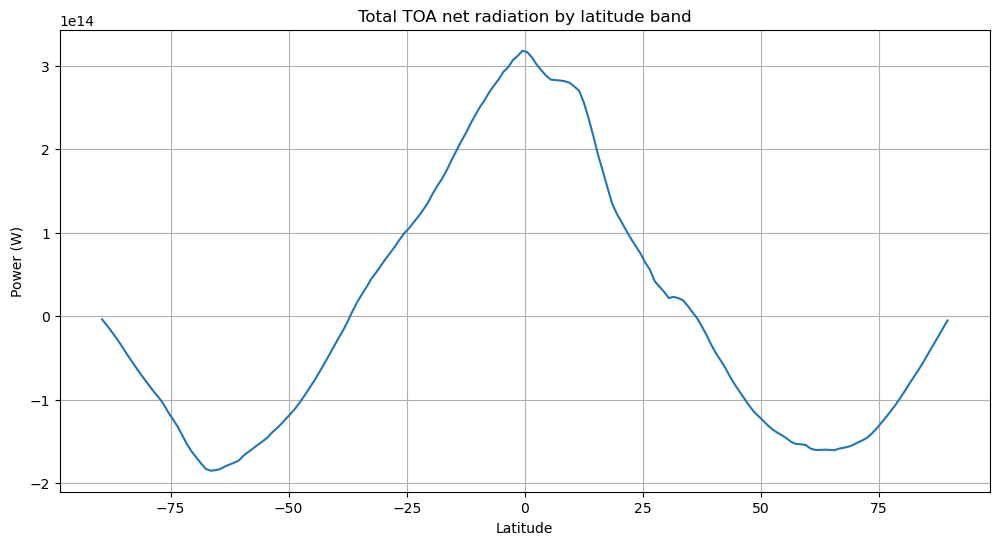

In [20]:
# W/m^2 * m^2 = W

net_power = ds_mean[net_var] * area
lat_band_power = net_power.sum(dim="lon")

lat_band_power.plot()
plt.title("Total TOA net radiation by latitude band")
plt.xlabel("Latitude")
plt.ylabel("Power (W)")
plt.grid(True)
plt.show()

### 4.3) Plot the cumulative sum of the total amount of net radiation as a function of latitude

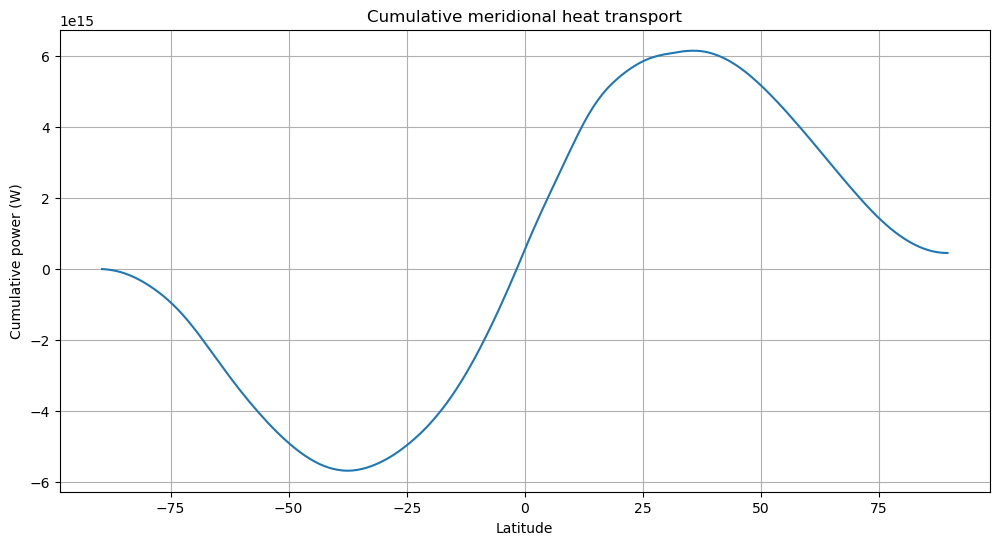

In [21]:
lat_band_power_sorted = lat_band_power.sortby("lat")
mht = lat_band_power_sorted.cumsum(dim="lat")

mht.plot()
plt.title("Cumulative meridional heat transport")
plt.xlabel("Latitude")
plt.ylabel("Cumulative power (W)")
plt.grid(True)
plt.show()

## 5) Making Maps with Cartopy

### 5.1) Plot data from NARR

In [22]:
hgt_url = "https://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/NARR/Dailies/pressure/hgt.201810.nc"
apcp_url = "https://www.esrl.noaa.gov/psd/thredds/dodsC/Datasets/NARR/Dailies/monolevel/apcp.2018.nc"

ds_hgt = xr.open_dataset(hgt_url, engine="netcdf4")
ds_apcp = xr.open_dataset(apcp_url, engine="netcdf4")

ds_hgt

/home/yk3149/.conda/envs/xarray-cartopy/lib/python3.11/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'hgt' has multiple fill values {np.float32(9.96921e+36), np.float32(-9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/yk3149/.conda/envs/xarray-cartopy/lib/python3.11/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'apcp' has multiple fill values {np.float32(9.96921e+36), np.float32(-9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


<xarray.Dataset> Size: 348MB
Dimensions:            (time: 31, nbnds: 2, level: 29, y: 277, x: 349)
Coordinates:
  * time               (time) datetime64[ns] 248B 2018-10-01 ... 2018-10-31
  * level              (level) float32 116B 1e+03 975.0 950.0 ... 125.0 100.0
  * y                  (y) float32 1kB 0.0 3.246e+04 ... 8.927e+06 8.96e+06
  * x                  (x) float32 1kB 0.0 3.246e+04 ... 1.126e+07 1.13e+07
    lat                (y, x) float32 387kB ...
    lon                (y, x) float32 387kB ...
Dimensions without coordinates: nbnds
Data variables:
    Lambert_Conformal  int32 4B ...
    time_bnds          (time, nbnds) float64 496B ...
    hgt                (time, level, y, x) float32 348MB ...
Attributes: (12/17)
    _NCProperties:                   version=1|netcdflibversion=4.4.1.1|hdf5l...
    Conventions:                     CF-1.2
    centerlat:                       50.0
    centerlon:                       -107.0
    comments:                        
    institution:                     National Centers for Environmental Predi...
    ...                              ...
    title:                           Daily NARR
    history:                         created Sat Mar 26 07:07:59 MDT 2016 by ...
    dataset_title:                   NCEP North American Regional Reanalysis ...
    references:                      https://www.esrl.noaa.gov/psd/data/gridd...
    source:                          http://www.emc.ncep.noaa.gov/mmb/rreanl/...
    DODS_EXTRA.Unlimited_Dimension:  time

In [23]:
ds_apcp

<xarray.Dataset> Size: 142MB
Dimensions:            (time: 365, nbnds: 2, y: 277, x: 349)
Coordinates:
  * time               (time) datetime64[ns] 3kB 2018-01-01 ... 2018-12-31
  * y                  (y) float32 1kB 0.0 3.246e+04 ... 8.927e+06 8.96e+06
  * x                  (x) float32 1kB 0.0 3.246e+04 ... 1.126e+07 1.13e+07
    lat                (y, x) float32 387kB ...
    lon                (y, x) float32 387kB ...
Dimensions without coordinates: nbnds
Data variables:
    Lambert_Conformal  int32 4B ...
    time_bnds          (time, nbnds) float64 6kB ...
    apcp               (time, y, x) float32 141MB ...
Attributes: (12/17)
    _NCProperties:                   version=1|netcdflibversion=4.4.1.1|hdf5l...
    Conventions:                     CF-1.2
    centerlat:                       50.0
    centerlon:                       -107.0
    comments:                        
    institution:                     National Centers for Environmental Predi...
    ...                              ...
    title:                           Daily NARR
    history:                         created Sat Mar 26 04:56:06 MDT 2016 by ...
    dataset_title:                   NCEP North American Regional Reanalysis ...
    references:                      https://www.esrl.noaa.gov/psd/data/gridd...
    source:                          http://www.emc.ncep.noaa.gov/mmb/rreanl/...
    DODS_EXTRA.Unlimited_Dimension:  time

In [26]:
import sys
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature

/home/yk3149/.conda/envs/xarray-cartopy/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/yk3149/.conda/envs/xarray-cartopy/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/yk3149/.conda/envs/xarray-cartopy/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


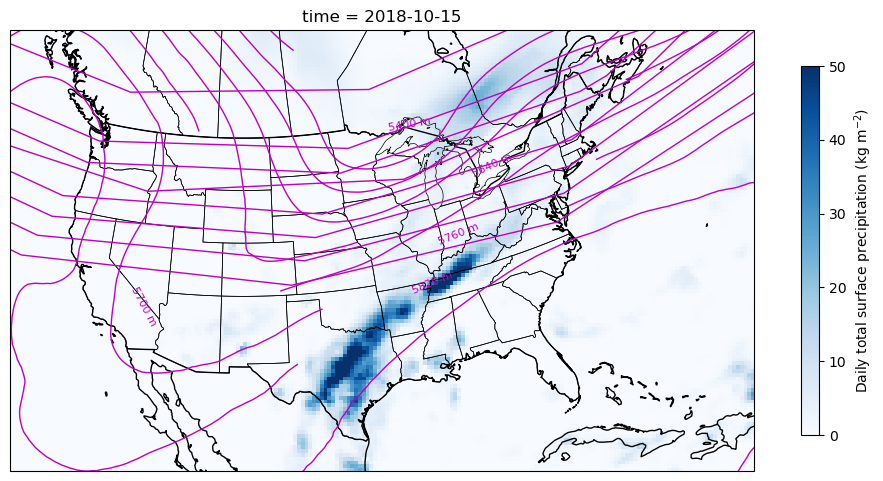

In [28]:
hgt_500 = ds_hgt["hgt"].sel(time="2018-10-15", level=500)
apcp_day = ds_apcp["apcp"].sel(time="2018-10-15")

proj_narr = ccrs.LambertConformal(
    central_longitude=-107.0,
    central_latitude=50.0,
    standard_parallels=(50.0, 50.0)
)

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=proj_narr)

# precipitation shading
pcm = ax.pcolormesh(
    ds_apcp["lon"],
    ds_apcp["lat"],
    apcp_day,
    transform=ccrs.PlateCarree(),
    cmap="Blues",
    vmin=0,
    vmax=50
)

cb = plt.colorbar(pcm, ax=ax, shrink=0.8)
cb.set_label("Daily total surface precipitation (kg m$^{-2}$)")

# 500 mb height contours
levels = np.arange(5100, 5910, 60)
cs = ax.contour(
    ds_hgt["lon"],
    ds_hgt["lat"],
    hgt_500,
    levels=levels,
    colors="m",
    linewidths=1.0,
    transform=ccrs.PlateCarree()
)
ax.clabel(cs, inline=True, fontsize=8, fmt="%d m")

ax.coastlines()
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, linewidth=0.5)

# zoom to CONUS
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

ax.set_title("time = 2018-10-15")
plt.show()

### 5.2) Antarctic Sea Ice

In [30]:
import xarray as xr
import pooch
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

url = "https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc"

fname = pooch.retrieve(
    url,
    known_hash="19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c"
)

ds_ice = xr.open_dataset(fname, drop_variables="melt_onset_day_seaice_conc_cdr")
ds_ice

<xarray.Dataset> Size: 4MB
Dimensions:                     (time: 1, ygrid: 332, xgrid: 316)
Coordinates:
  * time                        (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid                       (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                       (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
    latitude                    (ygrid, xgrid) float64 839kB ...
    longitude                   (ygrid, xgrid) float64 839kB ...
Data variables:
    projection                  |S1 1B ...
    seaice_conc_cdr             (time, ygrid, xgrid) float32 420kB ...
    stdev_of_seaice_conc_cdr    (time, ygrid, xgrid) float32 420kB ...
    qa_of_seaice_conc_cdr       (time, ygrid, xgrid) float32 420kB ...
    goddard_merged_seaice_conc  (time, ygrid, xgrid) float32 420kB ...
    goddard_nt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
    goddard_bt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
Attributes: (12/70)
    references:                             Comiso, J. C., and F. Nishio. 200...
    program:                                NOAA Climate Data Record Program
    cdr_variable:                           seaice_conc_cdr
    software_version_id:                    git@bitbucket.org:nsidc/seaice_cd...
    Metadata_Link:                          https://nsidc.org/api/dataset/met...
    product_version:                        v03r01
    ...                                     ...
    scaling_factor:                         1.0
    false_easting:                          0.0
    false_northing:                         0.0
    semimajor_radius:                       6378273.0
    semiminor_radius:                       6356889.449
    proj_units:                             meters

In [31]:
print(ds_ice)
print(ds_ice.data_vars)

<xarray.Dataset> Size: 4MB
Dimensions:                     (time: 1, ygrid: 332, xgrid: 316)
Coordinates:
  * time                        (time) datetime64[ns] 8B 2017-08-07T12:00:00
  * ygrid                       (ygrid) float32 1kB 4.338e+06 ... -3.938e+06
  * xgrid                       (xgrid) float32 1kB -3.938e+06 ... 3.938e+06
    latitude                    (ygrid, xgrid) float64 839kB ...
    longitude                   (ygrid, xgrid) float64 839kB ...
Data variables:
    projection                  |S1 1B ...
    seaice_conc_cdr             (time, ygrid, xgrid) float32 420kB ...
    stdev_of_seaice_conc_cdr    (time, ygrid, xgrid) float32 420kB ...
    qa_of_seaice_conc_cdr       (time, ygrid, xgrid) float32 420kB ...
    goddard_merged_seaice_conc  (time, ygrid, xgrid) float32 420kB ...
    goddard_nt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
    goddard_bt_seaice_conc      (time, ygrid, xgrid) float32 420kB ...
Attributes: (12/70)
    references:             

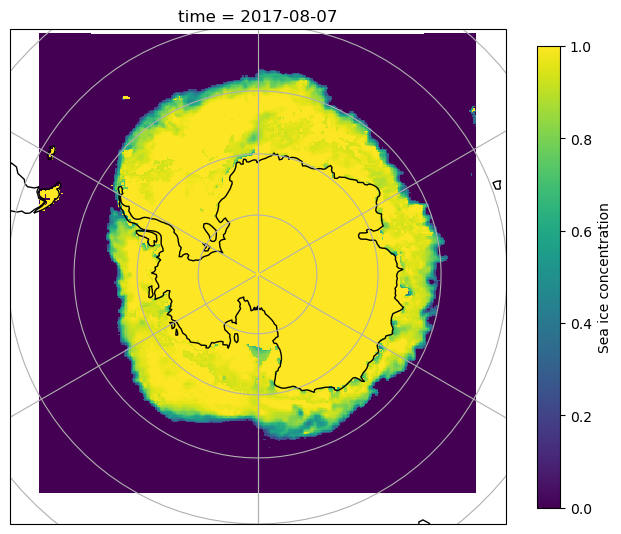

In [32]:
ice = ds_ice["seaice_conc_cdr"]

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

pcm = ax.pcolormesh(
    ds_ice["longitude"],
    ds_ice["latitude"],
    ice.squeeze(),
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=0,
    vmax=1
)

cb = plt.colorbar(pcm, ax=ax, shrink=0.75)
cb.set_label("Sea ice concentration")

ax.coastlines()
ax.gridlines()
ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax.set_title("time = 2017-08-07")

plt.show()

### 5.3) Global USGS Earthquakes

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Load earthquake data
url = "http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv"
df = pd.read_csv(url, parse_dates=["time"])

df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake


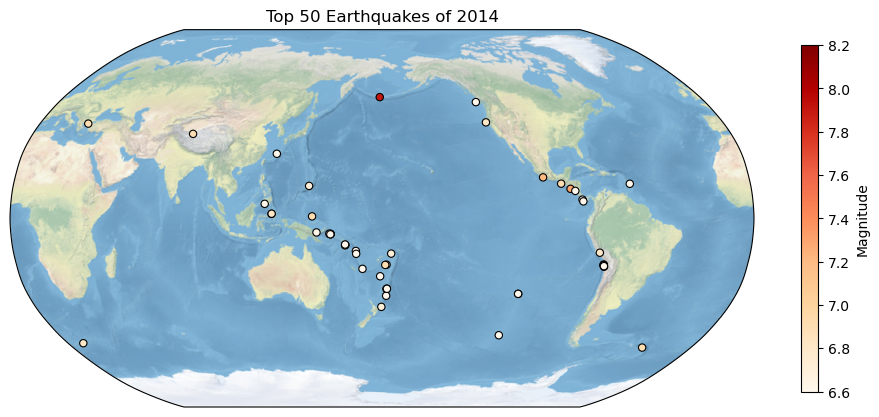

In [4]:
top50 = df.nlargest(50, "mag")

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))

ax.set_global()
ax.stock_img()

sc = ax.scatter(
    top50["longitude"],
    top50["latitude"],
    c=top50["mag"],
    s=28,
    cmap="OrRd",
    vmin=6.6,
    vmax=8.2,
    edgecolors="black",
    linewidths=0.8,
    transform=ccrs.PlateCarree(),
    zorder=5
)

cb = plt.colorbar(sc, ax=ax, shrink=0.75, pad=0.05)
cb.set_label("Magnitude")

ax.set_title("Top 50 Earthquakes of 2014")
plt.show()